
# Lorenz63 Analysis

This notebook evaluates the pretrained Lorenz63 models released with EncoderOps and compares them against simple operator-learning baselines. It defaults to the Hugging Face checkpoints and dataset, but it can also read locally trained checkpoints by changing a single parameter cell.

The structure is intentionally compact:
- one parameter cell
- one helper layer with reusable functions
- one short run-and-display cell per method
- one final comparison table


In [1]:

import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    for candidate in REPO_ROOT.parents:
        if (candidate / "src").exists():
            REPO_ROOT = candidate
            break

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT


PosixPath('/home/gturri-iit.local/projects/encoderops')

## Notebook Parameters

In [2]:

checkpoint_source = "hf"  # "hf" or "local"
checkpoint_repo_id = "CSML-IIT/encoderops"
local_checkpoint_root = REPO_ROOT

dataset_root = None  # Set to a path if you want to override DATA_PATH.
data_lagtime = 1
data_history_len = 0

checkpoint_replicas = list(range(20))
representative_replicas = {
    "Evolution Operator": 6,
    "VAMPNets": 0,
    "DPNets": 0,
    "DAE": 0,
    "CAE": 0,
}

latent_dim = 8
kernel_repeats = 20
kernel_rank = 11
kernel_tikhonov_reg = 1e-6
kernel_reduced_rank = True
evop_regularization = 1e-5
max_trajectory_runs = 10
eigenfunctions_to_plot = 4

save_figures = False
figure_dir = REPO_ROOT / "figures" / "lorenz63_analysis"
if save_figures:
    figure_dir.mkdir(parents=True, exist_ok=True)


## Imports

In [3]:

import warnings
from time import perf_counter

import linear_operator_learning as lol
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from IPython.display import display
from kooplearn.data import traj_to_contexts
from kooplearn.models import Kernel, Linear, Nonlinear
from kooplearn.models.ae.utils import encode_contexts
from kooplearn.models.feature_maps.nn import NNFeatureMap
from kooplearn.nn.data import collate_context_dataset
from linear_operator_learning.nn import MLP
from scipy.spatial.distance import pdist
from sklearn.gaussian_process.kernels import RBF
from torch import nn
from torch.utils.data import DataLoader

from exps.lorenz63.cae import ConsistentAE
from exps.lorenz63.dae import DynamicAE
from src.checkpoints import resolve_checkpoint_path
from src.configs import Lorenz63DataArgs, TrainerArgs
from src.data import Lorenz63DataModule
from src.model import EvolutionOperator

load_dotenv()

warnings.filterwarnings(
    "ignore",
    message="Found keys that are in the model state dict.*covariances\.is_initialized.*",
)
warnings.filterwarnings("ignore", category=FutureWarning, module="kooplearn._src.serialization")


## Analysis Helpers

In [4]:

# The Lorenz63 baseline checkpoints were serialized with __main__.MLPEncoder / MLPDecoder.
# Re-declare them here so the notebook loads the published checkpoints in a fresh kernel.
class MLPEncoder(nn.Module):
    def __init__(
        self,
        input_shape,
        n_hidden,
        layer_size,
        output_shape,
        dropout=0.0,
        activation=nn.ReLU,
        iterative_whitening=False,
        bias=True,
    ):
        super().__init__()
        self.encoder = MLP(
            input_shape=input_shape,
            n_hidden=n_hidden,
            layer_size=layer_size,
            output_shape=output_shape,
            dropout=dropout,
            activation=activation,
            iterative_whitening=iterative_whitening,
            bias=bias,
        )

    def forward(self, x):
        encoded = self.encoder(x)
        return torch.cat([encoded, x], dim=-1)


class MLPDecoder(nn.Module):
    def __init__(
        self,
        input_shape,
        n_hidden,
        layer_size,
        output_shape,
        dropout=0.0,
        activation=nn.ReLU,
        iterative_whitening=False,
        bias=True,
    ):
        super().__init__()
        self.decoder = MLP(
            input_shape=input_shape,
            n_hidden=n_hidden,
            layer_size=layer_size,
            output_shape=output_shape,
            dropout=dropout,
            activation=activation,
            iterative_whitening=iterative_whitening,
            bias=bias,
        )

    def forward(self, x):
        return self.decoder(x)


main_module = sys.modules.get("__main__")
if main_module is not None:
    main_module.MLPEncoder = MLPEncoder
    main_module.MLPDecoder = MLPDecoder


def make_checkpoint_path(relative_path, repo_type="model"):
    if checkpoint_source == "local":
        return resolve_checkpoint_path(
            source="local",
            local_path=Path(local_checkpoint_root) / relative_path,
        )
    return resolve_checkpoint_path(
        source="hf",
        repo_id=checkpoint_repo_id,
        filename=relative_path,
        repo_type=repo_type,
    )


def figure_slug(name):
    slug = name.lower().replace(" ", "_").replace("/", "_").replace("-", "_")
    return slug.replace("__", "_")


def maybe_save_figure(fig, stem):
    if save_figures:
        fig.savefig(figure_dir / f"{stem}.png", dpi=300, bbox_inches="tight")


def to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def rmse(prediction, target):
    prediction = np.asarray(prediction)
    target = np.asarray(target)
    return float(np.sqrt(np.mean((prediction - target) ** 2)))


def mae(prediction, target):
    prediction = np.asarray(prediction)
    target = np.asarray(target)
    return float(np.mean(np.abs(prediction - target)))


def sort_eigendecomposition(eigenvalues, left_eigenfunctions, right_eigenfunctions):
    eigenvalues = to_numpy(eigenvalues)
    left_eigenfunctions = to_numpy(left_eigenfunctions)
    right_eigenfunctions = to_numpy(right_eigenfunctions)

    magnitudes = np.round(np.abs(eigenvalues), decimals=8)
    _, unique_indices = np.unique(magnitudes, return_index=True)
    unique_indices = np.sort(unique_indices)

    eigenvalues = eigenvalues[unique_indices]
    left_eigenfunctions = left_eigenfunctions[:, unique_indices]
    right_eigenfunctions = right_eigenfunctions[:, unique_indices]

    order = np.argsort(-np.abs(eigenvalues))
    return (
        eigenvalues[order],
        left_eigenfunctions[:, order],
        right_eigenfunctions[:, order],
    )


def build_lorenz63_analysis_data():
    if data_history_len != 0 or data_lagtime != 1:
        raise ValueError(
            "The published Lorenz63 notebook assumes lagtime=1 and history_len=0. "
            "Change the checkpoints or extend the helper logic before changing these values."
        )

    trainer_args = TrainerArgs(batch_size=512)
    data_args = Lorenz63DataArgs(
        lagtime=data_lagtime,
        history_len=data_history_len,
        data_path=None if dataset_root is None else str(dataset_root),
    )
    datamodule = Lorenz63DataModule(trainer_args, data_args, num_workers=0)
    datamodule.prepare_data()
    datamodule.setup("fit")

    train_dataset = datamodule.train_dataset
    test_dataset = datamodule.test_dataset
    train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
    train_inputs, train_targets = next(iter(train_loader))
    _, test_targets = next(iter(test_loader))

    train_series = train_dataset.data.astype("float32")
    test_series = test_dataset.data.astype("float32")
    train_contexts = traj_to_contexts(train_series, time_lag=data_lagtime, backend="numpy")
    test_contexts = traj_to_contexts(test_series, time_lag=data_lagtime, backend="numpy")

    summary = pd.DataFrame(
        [
            {
                "split": "train",
                "num_samples": len(train_dataset),
                "series_length": len(train_series),
                "num_variables": train_series.shape[1],
            },
            {
                "split": "test",
                "num_samples": len(test_dataset),
                "series_length": len(test_series),
                "num_variables": test_series.shape[1],
            },
        ]
    ).set_index("split")

    return {
        "datamodule": datamodule,
        "train_dataset": train_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader,
        "test_loader": test_loader,
        "train_inputs": train_inputs.numpy(),
        "train_targets": train_targets.numpy(),
        "truth": test_targets.numpy(),
        "train_series": train_series,
        "test_series": test_series,
        "train_contexts": train_contexts,
        "test_contexts": test_contexts,
        "num_variables": train_series.shape[1],
        "summary": summary,
        "data_path": datamodule.data_path,
    }


def summary_row(result):
    run_metrics = result["run_metrics"]
    fit_times = run_metrics["fit_time_ms"].dropna().to_numpy() if "fit_time_ms" in run_metrics else np.array([])
    return {
        "method": result["name"],
        "runs": int(len(run_metrics)),
        "rmse_mean": float(run_metrics["rmse"].mean()),
        "rmse_std": float(run_metrics["rmse"].std(ddof=0)),
        "mae_mean": float(run_metrics["mae"].mean()),
        "mae_std": float(run_metrics["mae"].std(ddof=0)),
        "fit_time_ms_mean": float(fit_times.mean()) if fit_times.size else np.nan,
        "fit_time_ms_std": float(fit_times.std(ddof=0)) if fit_times.size else np.nan,
        "representative_run": result.get("representative_replica"),
    }


def summarize_analyses(results):
    comparison = pd.DataFrame(summary_row(result) for result in results)
    return comparison.set_index("method")


def select_prediction_runs(prediction_runs, max_runs=max_trajectory_runs):
    if len(prediction_runs) <= max_runs:
        return prediction_runs
    indices = np.linspace(0, len(prediction_runs) - 1, max_runs, dtype=int)
    indices = np.unique(indices)
    return [prediction_runs[index] for index in indices]


def format_eigenvalue(eigenvalue):
    if np.isclose(eigenvalue.imag, 0.0):
        return f"{eigenvalue.real:.3f}"
    imag = abs(eigenvalue.imag)
    sign = "+" if eigenvalue.imag >= 0 else "-"
    return f"{eigenvalue.real:.3f} {sign} {imag:.3f}i"


def plot_prediction_trajectories(result):
    fig = plt.figure(figsize=(6, 6), dpi=120)
    axis = fig.add_subplot(111, projection="3d")

    for index, prediction in enumerate(select_prediction_runs(result["prediction_runs"])):
        label = "Predictions" if index == 0 else "_nolegend_"
        axis.plot(
            prediction[:, 0],
            prediction[:, 1],
            prediction[:, 2],
            color="tab:orange",
            alpha=0.35,
            lw=1.0,
            label=label,
        )

    truth = result["truth"]
    axis.plot(
        truth[:, 0],
        truth[:, 1],
        truth[:, 2],
        color="black",
        lw=2.0,
        label="Ground truth",
    )

    axis.set_title(f"{result['name']}: one-step predictions")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_zlabel("z")
    axis.legend(loc="upper left")
    fig.tight_layout()
    maybe_save_figure(fig, f"{figure_slug(result['name'])}_trajectory")
    plt.show()


def plot_eigenfunctions(result, analysis_data):
    eigenvalues = result["eigenvalues"]
    right_eigenfunctions = result["right_eigenfunctions"]
    coordinates = analysis_data["train_inputs"]
    num_modes = min(eigenfunctions_to_plot, len(eigenvalues))

    fig, axes = plt.subplots(1, num_modes, figsize=(2.8 * num_modes, 2.8), dpi=120)
    axes = np.atleast_1d(axes)

    for mode_index, axis in enumerate(axes[:num_modes]):
        eigenfunction = right_eigenfunctions[:, mode_index].real
        color_limit = max(np.max(np.abs(eigenfunction)), 1e-12)
        axis.scatter(
            coordinates[:, 0],
            coordinates[:, 2],
            c=eigenfunction,
            cmap="PRGn",
            s=8,
            alpha=0.5,
            vmin=-color_limit,
            vmax=color_limit,
            linewidths=0,
        )
        axis.set_title(rf"$\lambda_{{{mode_index + 1}}}$ = {format_eigenvalue(eigenvalues[mode_index])}")
        axis.set_xlabel("x")
        if mode_index == 0:
            axis.set_ylabel("z")
        axis.set_xticks([])
        axis.set_yticks([])
        for spine in axis.spines.values():
            spine.set_visible(False)

    fig.suptitle(f"{result['name']}: leading right eigenfunctions", y=1.02)
    fig.tight_layout()
    maybe_save_figure(fig, f"{figure_slug(result['name'])}_eigenfunctions")
    plt.show()


def show_analysis(result, analysis_data):
    display(pd.DataFrame([summary_row(result)]).set_index("method"))
    if result.get("failed_runs"):
        failed_runs = ", ".join(str(run) for run in sorted(result["failed_runs"]))
        print(f"Skipped runs: {failed_runs}")
    plot_prediction_trajectories(result)
    plot_eigenfunctions(result, analysis_data)


@torch.no_grad()
def get_evop_embeddings(model, loader):
    model = model.eval()
    inputs, targets = next(iter(loader))
    inputs = inputs.to(model.device)
    targets = targets.to(model.device)
    emb_inputs = model.normalizer(model.encoder(inputs))
    emb_targets = model.normalizer(model.encoder(targets))
    emb_inputs = torch.cat([emb_inputs, inputs], dim=-1)
    emb_targets = torch.cat([emb_targets, targets], dim=-1)
    return emb_inputs, emb_targets, inputs, targets


@torch.no_grad()
def estimate_transfer_operator(emb_inputs, emb_targets, regularization):
    cov_inputs = lol.nn.stats.covariance(emb_inputs)
    cov_inputs = cov_inputs + regularization * torch.eye(cov_inputs.shape[0], device=cov_inputs.device)
    cov_input_target = lol.nn.stats.covariance(emb_inputs, emb_targets)
    return torch.linalg.solve(cov_inputs, cov_input_target)


def load_evop_checkpoint(replica):
    checkpoint_path = make_checkpoint_path(
        f"lorenz63/EvolutionOperator_dataopt/EvOp_rep{replica}.pt"
    )
    return EvolutionOperator.load_from_checkpoint(
        checkpoint_path,
        map_location="cpu",
        strict=False,
    )


def evaluate_evop_model(model, analysis_data):
    train_inputs, train_targets, _, _ = get_evop_embeddings(model, analysis_data["train_loader"])
    transfer_operator = estimate_transfer_operator(train_inputs.cpu(), train_targets.cpu(), evop_regularization)
    test_inputs, _, _, truth = get_evop_embeddings(model, analysis_data["test_loader"])
    predictions = (test_inputs.cpu() @ transfer_operator)[:, -analysis_data["num_variables"] :].numpy()
    truth = truth.cpu().numpy()
    return {
        "predictions": predictions,
        "truth": truth,
        "rmse": rmse(predictions, truth),
        "mae": mae(predictions, truth),
    }


def analyze_evop_model(model, analysis_data):
    emb_inputs, emb_targets, _, _ = get_evop_embeddings(model, analysis_data["train_loader"])
    transfer_operator = estimate_transfer_operator(emb_inputs, emb_targets, evop_regularization)
    eigenvalues, eigenvectors = torch.linalg.eig(transfer_operator)
    cov_targets = lol.nn.stats.covariance(emb_targets)
    regularized_cov_targets = cov_targets + evop_regularization * torch.eye(
        cov_targets.shape[0],
        dtype=cov_targets.dtype,
        device=cov_targets.device,
    )
    right_eigenfunctions = emb_inputs.to(eigenvectors.dtype) @ eigenvectors
    left_eigenfunctions = torch.linalg.solve(
        regularized_cov_targets.to(eigenvectors.dtype) @ eigenvectors,
        emb_inputs.to(eigenvectors.dtype).T,
    ).T
    eigenvalues, left_eigenfunctions, right_eigenfunctions = sort_eigendecomposition(
        eigenvalues,
        left_eigenfunctions,
        right_eigenfunctions,
    )
    return {
        "eigenvalues": eigenvalues,
        "left_eigenfunctions": left_eigenfunctions,
        "right_eigenfunctions": right_eigenfunctions,
    }


def fit_nonlinear_model(feature_map, analysis_data):
    return Nonlinear(
        feature_map,
        reduced_rank=False,
        rank=latent_dim + analysis_data["num_variables"],
    ).fit(analysis_data["train_contexts"])


def load_feature_map_checkpoint(subdir, prefix, replica):
    checkpoint_path = make_checkpoint_path(f"lorenz63/{subdir}/{prefix}_rep{replica}.pt")
    return NNFeatureMap.load(checkpoint_path)


def evaluate_feature_map(feature_map, analysis_data):
    nonlinear_model = fit_nonlinear_model(feature_map, analysis_data)
    predictions = nonlinear_model.predict(analysis_data["test_contexts"], t=1).reshape(
        -1,
        analysis_data["num_variables"],
    )
    truth = analysis_data["truth"]
    return {
        "predictions": predictions,
        "truth": truth,
        "rmse": rmse(predictions, truth),
        "mae": mae(predictions, truth),
    }


def analyze_feature_map(feature_map, analysis_data):
    nonlinear_model = fit_nonlinear_model(feature_map, analysis_data)
    eigenvalues, left_eigenfunctions, right_eigenfunctions = nonlinear_model.eig(
        eval_right_on=analysis_data["train_contexts"],
        eval_left_on=analysis_data["train_contexts"],
    )
    eigenvalues, left_eigenfunctions, right_eigenfunctions = sort_eigendecomposition(
        eigenvalues,
        left_eigenfunctions,
        right_eigenfunctions,
    )
    return {
        "eigenvalues": eigenvalues,
        "left_eigenfunctions": left_eigenfunctions,
        "right_eigenfunctions": right_eigenfunctions,
    }


def recompute_autoencoder_operator(model, analysis_data):
    context_loader = DataLoader(
        analysis_data["train_contexts"],
        batch_size=len(analysis_data["train_contexts"]),
        shuffle=False,
        collate_fn=collate_context_dataset,
        num_workers=1,
    )
    context_batch = next(iter(context_loader))
    encoded_batch = encode_contexts(context_batch, model.lightning_module.encoder)
    emb_inputs = encoded_batch.data[:, 0, ...]
    emb_targets = encoded_batch.data[:, 1, ...]
    evolution_operator = torch.linalg.lstsq(emb_inputs, emb_targets).solution.T
    model.lightning_module.evolution_operator = nn.Parameter(evolution_operator)
    return model


def load_autoencoder_checkpoint(model_cls, subdir, prefix, replica, analysis_data):
    checkpoint_path = make_checkpoint_path(f"lorenz63/{subdir}/{prefix}_rep{replica}.pt")
    model = model_cls.load(checkpoint_path)
    return recompute_autoencoder_operator(model, analysis_data)


def evaluate_autoencoder(model, analysis_data):
    predictions = model.predict(analysis_data["test_contexts"], t=1).reshape(
        -1,
        analysis_data["num_variables"],
    )
    truth = analysis_data["truth"]
    return {
        "predictions": predictions,
        "truth": truth,
        "rmse": rmse(predictions, truth),
        "mae": mae(predictions, truth),
    }


def analyze_autoencoder(model, analysis_data):
    eigenvalues, left_eigenfunctions, right_eigenfunctions = model.eig(
        eval_right_on=analysis_data["train_contexts"],
        eval_left_on=analysis_data["train_contexts"],
    )
    eigenvalues, left_eigenfunctions, right_eigenfunctions = sort_eigendecomposition(
        eigenvalues,
        left_eigenfunctions,
        right_eigenfunctions,
    )
    return {
        "eigenvalues": eigenvalues,
        "left_eigenfunctions": left_eigenfunctions,
        "right_eigenfunctions": right_eigenfunctions,
    }


def run_checkpoint_ensemble(name, load_model, evaluate_model, analyze_model):
    run_rows = []
    prediction_runs = []
    failed_runs = {}
    truth = None

    for replica in checkpoint_replicas:
        try:
            model = load_model(replica)
            evaluation = evaluate_model(model)
        except Exception as exc:
            failed_runs[replica] = f"{type(exc).__name__}: {exc}"
            continue

        run_rows.append(
            {
                "run": replica,
                "rmse": evaluation["rmse"],
                "mae": evaluation["mae"],
                "fit_time_ms": np.nan,
            }
        )
        prediction_runs.append(evaluation["predictions"])
        truth = evaluation["truth"]

    if not run_rows:
        raise RuntimeError(f"No successful runs were loaded for {name}.")

    available_runs = [row["run"] for row in run_rows]
    representative = representative_replicas.get(name, available_runs[0])
    if representative not in available_runs:
        representative = available_runs[0]

    spectrum = analyze_model(load_model(representative))
    return {
        "name": name,
        "run_metrics": pd.DataFrame(run_rows),
        "prediction_runs": prediction_runs,
        "truth": truth,
        "representative_replica": representative,
        "failed_runs": failed_runs,
        **spectrum,
    }


def run_evop_analysis(analysis_data):
    return run_checkpoint_ensemble(
        "Evolution Operator",
        load_model=load_evop_checkpoint,
        evaluate_model=lambda model: evaluate_evop_model(model, analysis_data),
        analyze_model=lambda model: analyze_evop_model(model, analysis_data),
    )


def run_feature_map_analysis(name, subdir, prefix, analysis_data):
    return run_checkpoint_ensemble(
        name,
        load_model=lambda replica: load_feature_map_checkpoint(subdir, prefix, replica),
        evaluate_model=lambda feature_map: evaluate_feature_map(feature_map, analysis_data),
        analyze_model=lambda feature_map: analyze_feature_map(feature_map, analysis_data),
    )


def run_autoencoder_analysis(name, model_cls, subdir, prefix, analysis_data):
    return run_checkpoint_ensemble(
        name,
        load_model=lambda replica: load_autoencoder_checkpoint(
            model_cls,
            subdir,
            prefix,
            replica,
            analysis_data,
        ),
        evaluate_model=lambda model: evaluate_autoencoder(model, analysis_data),
        analyze_model=lambda model: analyze_autoencoder(model, analysis_data),
    )


def run_linear_analysis(analysis_data):
    start_time = perf_counter()
    linear_model = Linear(reduced_rank=False, rank=analysis_data["num_variables"]).fit(
        analysis_data["train_contexts"]
    )
    fit_time_ms = (perf_counter() - start_time) * 1000.0
    predictions = linear_model.predict(analysis_data["test_contexts"], t=1).reshape(
        -1,
        analysis_data["num_variables"],
    )
    eigenvalues, left_eigenfunctions, right_eigenfunctions = linear_model.eig(
        eval_right_on=analysis_data["train_contexts"],
        eval_left_on=analysis_data["train_contexts"],
    )
    eigenvalues, left_eigenfunctions, right_eigenfunctions = sort_eigendecomposition(
        eigenvalues,
        left_eigenfunctions,
        right_eigenfunctions,
    )
    return {
        "name": "Linear OLS",
        "run_metrics": pd.DataFrame(
            [
                {
                    "run": 0,
                    "rmse": rmse(predictions, analysis_data["truth"]),
                    "mae": mae(predictions, analysis_data["truth"]),
                    "fit_time_ms": fit_time_ms,
                }
            ]
        ),
        "prediction_runs": [predictions],
        "truth": analysis_data["truth"],
        "representative_replica": 0,
        "failed_runs": {},
        "eigenvalues": eigenvalues,
        "left_eigenfunctions": left_eigenfunctions,
        "right_eigenfunctions": right_eigenfunctions,
    }


def run_kernel_analysis(analysis_data):
    length_scale = np.quantile(pdist(analysis_data["train_series"]), 0.5)
    kernel = RBF(length_scale=length_scale)
    run_rows = []
    prediction_runs = []
    representative_model = None

    for repeat in range(kernel_repeats):
        start_time = perf_counter()
        model = Kernel(
            kernel=kernel,
            reduced_rank=kernel_reduced_rank,
            tikhonov_reg=kernel_tikhonov_reg,
            rank=kernel_rank,
        ).fit(analysis_data["train_contexts"])
        fit_time_ms = (perf_counter() - start_time) * 1000.0
        if representative_model is None:
            representative_model = model
        predictions = model.predict(analysis_data["test_contexts"], t=1).reshape(
            -1,
            analysis_data["num_variables"],
        )
        prediction_runs.append(predictions)
        run_rows.append(
            {
                "run": repeat,
                "rmse": rmse(predictions, analysis_data["truth"]),
                "mae": mae(predictions, analysis_data["truth"]),
                "fit_time_ms": fit_time_ms,
            }
        )

    eigenvalues, left_eigenfunctions, right_eigenfunctions = representative_model.eig(
        eval_right_on=analysis_data["train_contexts"],
        eval_left_on=analysis_data["train_contexts"],
    )
    eigenvalues, left_eigenfunctions, right_eigenfunctions = sort_eigendecomposition(
        eigenvalues,
        left_eigenfunctions,
        right_eigenfunctions,
    )
    return {
        "name": "Kernel Ridge Regression",
        "run_metrics": pd.DataFrame(run_rows),
        "prediction_runs": prediction_runs,
        "truth": analysis_data["truth"],
        "representative_replica": 0,
        "failed_runs": {},
        "eigenvalues": eigenvalues,
        "left_eigenfunctions": left_eigenfunctions,
        "right_eigenfunctions": right_eigenfunctions,
    }


## Data Setup

In [5]:

lorenz63_data = build_lorenz63_analysis_data()

print(f"Dataset root: {lorenz63_data['data_path']}")
display(lorenz63_data["summary"])


2026-04-17 19:58:14.309 | INFO     | src.data:__init__:954 - Dataset loaded with 9999 samples and 3 variables.
2026-04-17 19:58:14.415 | INFO     | src.data:__init__:954 - Dataset loaded with 999 samples and 3 variables.
2026-04-17 19:58:14.421 | INFO     | src.data:__init__:954 - Dataset loaded with 999 samples and 3 variables.


Dataset root: /mnt/data/datasets


,num_samples,series_length,num_variables
split,,,
train,9999,10000,3
test,999,1000,3


## Evolution Operator

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


EvOp_rep1.pt:   0%|          | 0.00/22.4k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


EvOp_rep2.pt:   0%|          | 0.00/22.4k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


EvOp_rep18.pt:   0%|          | 0.00/22.4k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


EvOp_rep19.pt:   0%|          | 0.00/22.4k [00:00<?, ?B/s]

,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
Evolution Operator,20,0.004912,0.002401,0.003221,0.002352,NaN,NaN,6


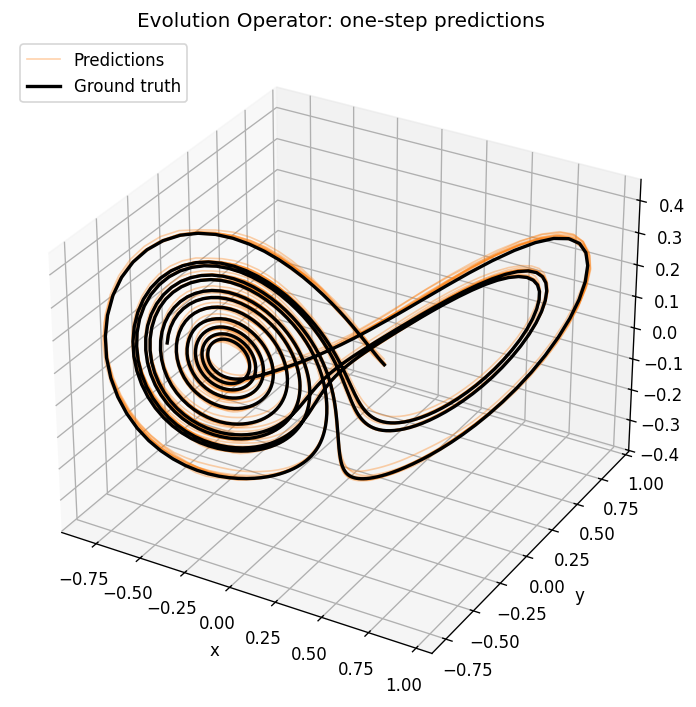

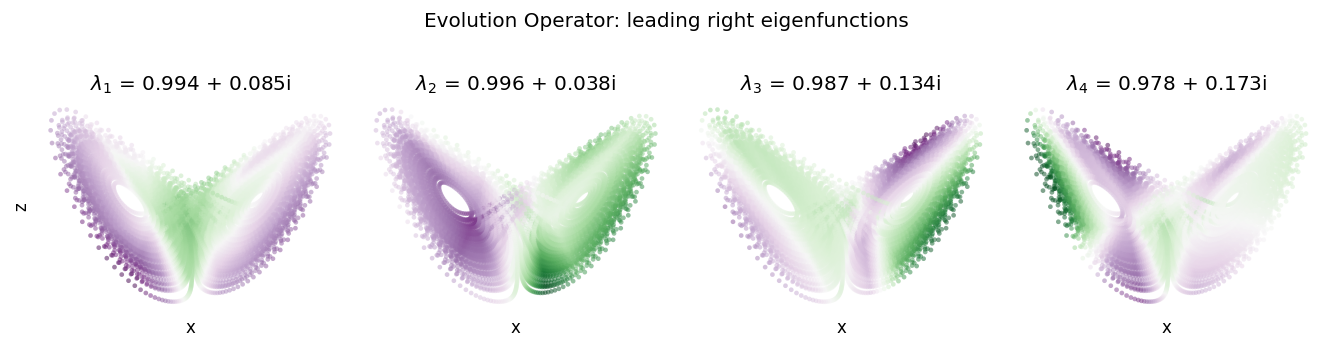

In [6]:

evop = run_evop_analysis(lorenz63_data)
show_analysis(evop, lorenz63_data)


## Linear Ordinary Least Squares

,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
Linear OLS,1,0.012912,0.0,0.008429,0.0,1.330889,0.0,0


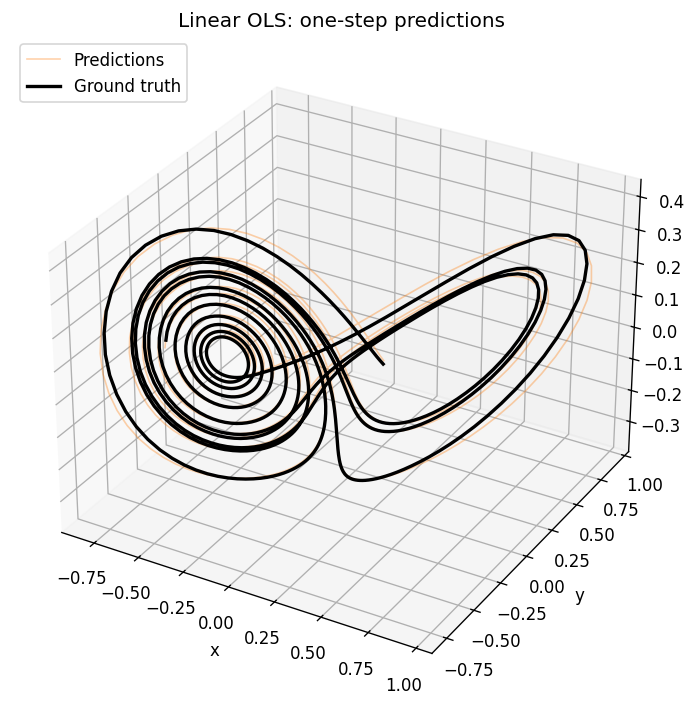

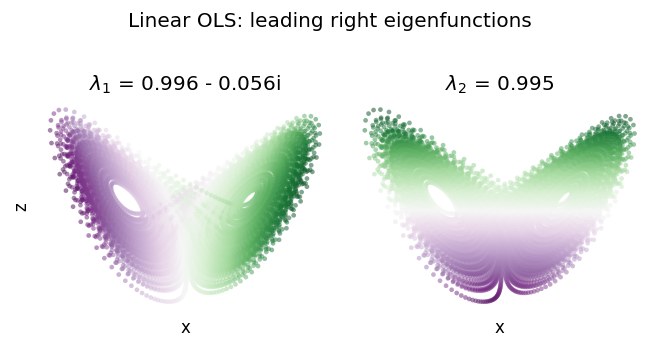

In [7]:

linear_ols = run_linear_analysis(lorenz63_data)
show_analysis(linear_ols, lorenz63_data)


## Kernel Ridge Regression

,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
Kernel Ridge Regression,20,0.020953,1.912946e-15,0.012689,7.877877e-16,7157.467104,593.452231,0


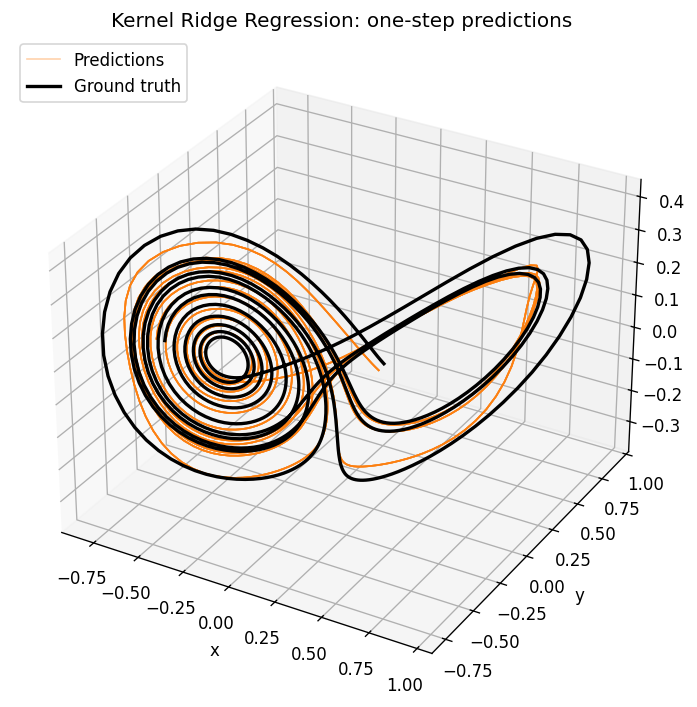

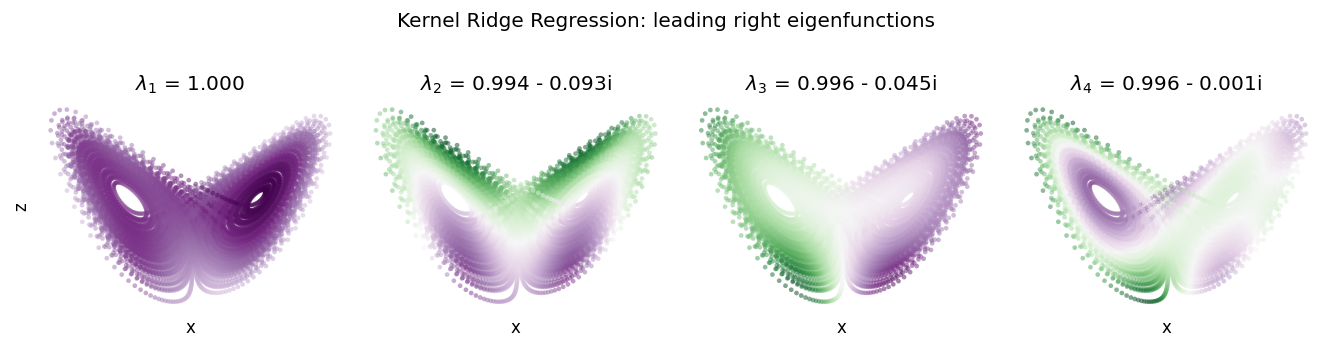

In [8]:

krr = run_kernel_analysis(lorenz63_data)
show_analysis(krr, lorenz63_data)


## VAMPNets

The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


VAMPNets_rep1.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


VAMPNets_rep2.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

The rank attribute has been updated to 5.
Consider decreasing the rank parameter.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

VAMPNets_rep18.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

The rank attribute has been updated to 6.
Consider decreasing the rank parameter.
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


VAMPNets_rep19.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

The rank attribute has been updated to 8.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.


,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
VAMPNets,20,0.007805,0.001247,0.004619,0.000826,NaN,NaN,0


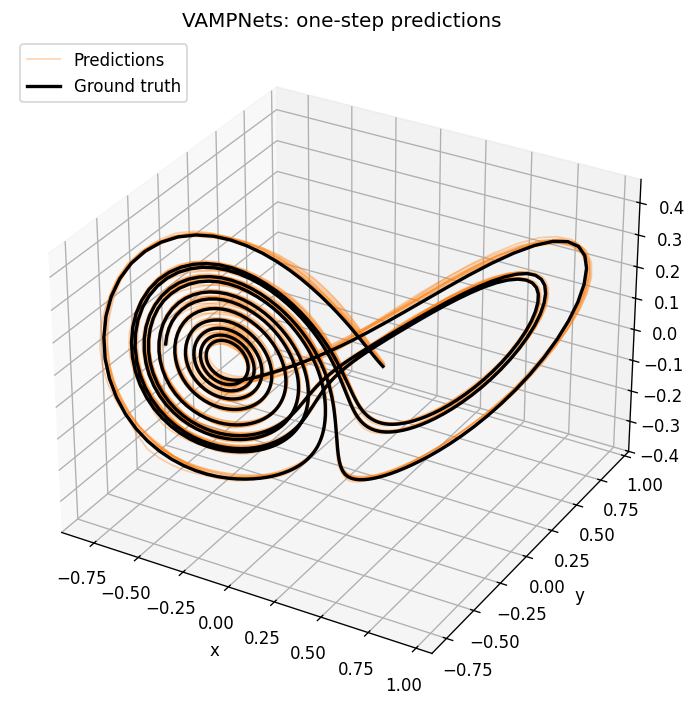

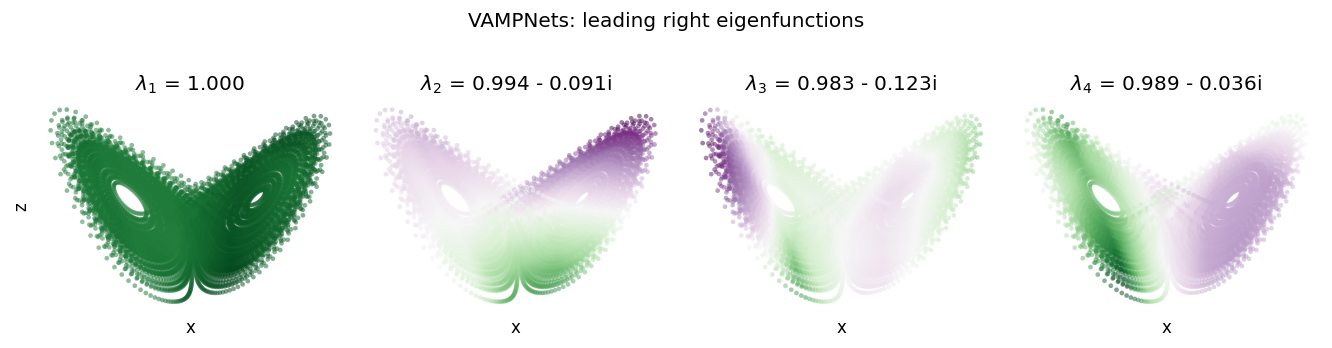

In [9]:

vampnets = run_feature_map_analysis(
    name="VAMPNets",
    subdir="VAMPNets",
    prefix="VAMPNets",
    analysis_data=lorenz63_data,
)
show_analysis(vampnets, lorenz63_data)


## DPNets

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DPNets_rep1.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DPNets_rep2.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DPNets_rep18.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DPNets_rep19.pt:   0%|          | 0.00/608k [00:00<?, ?B/s]

,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
DPNets,20,0.005809,0.001098,0.003574,0.00076,NaN,NaN,0


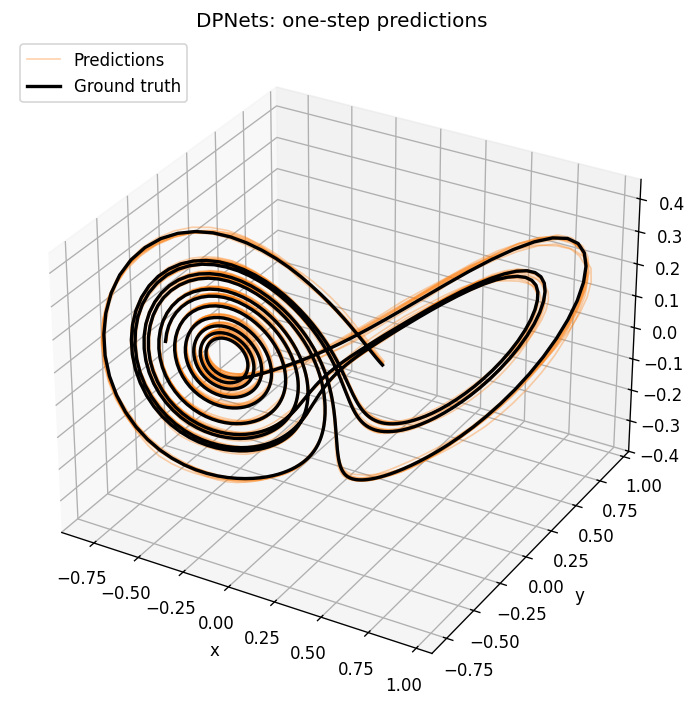

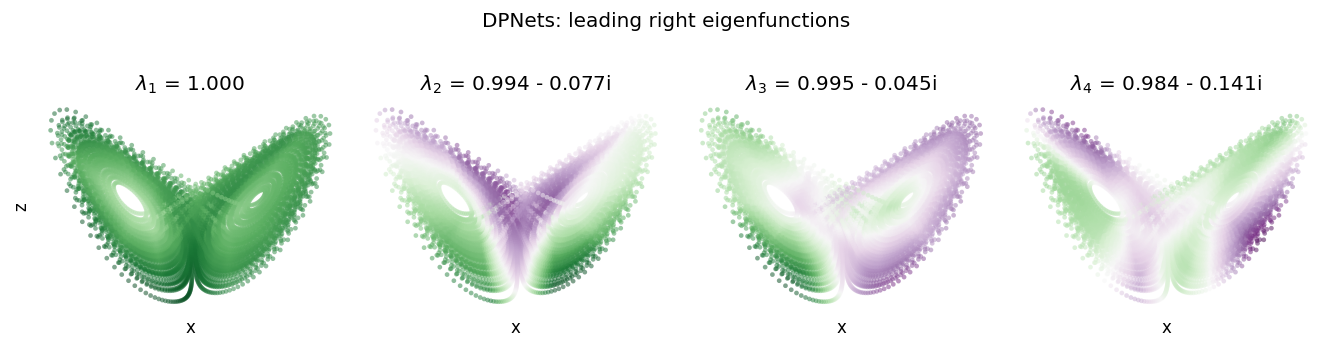

In [10]:

dpnets = run_feature_map_analysis(
    name="DPNets",
    subdir="DPNets",
    prefix="DPNets",
    analysis_data=lorenz63_data,
)
show_analysis(dpnets, lorenz63_data)


## Dynamic Autoencoder

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DAE_rep1.pt:   0%|          | 0.00/640k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DAE_rep2.pt:   0%|          | 0.00/640k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DAE_rep18.pt:   0%|          | 0.00/639k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


DAE_rep19.pt:   0%|          | 0.00/640k [00:00<?, ?B/s]

,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
DAE,20,0.007704,0.001161,0.00553,0.000813,NaN,NaN,0


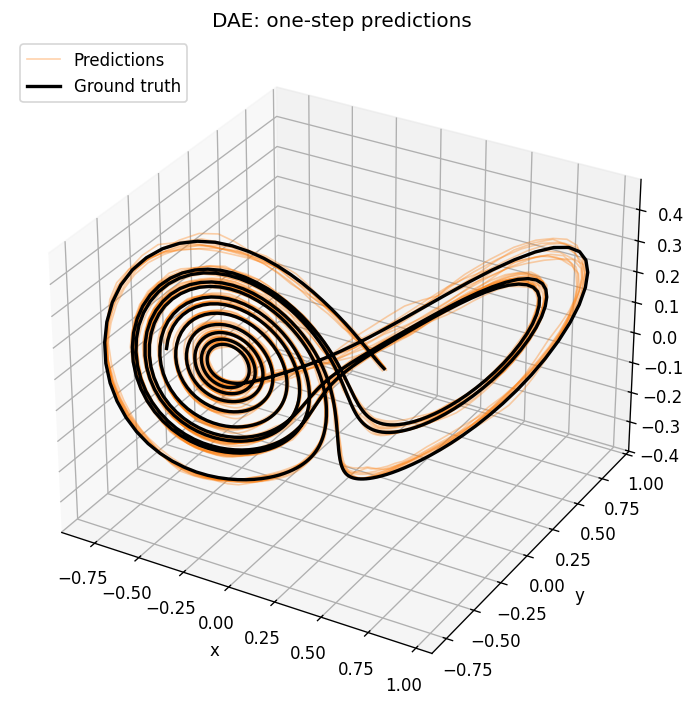

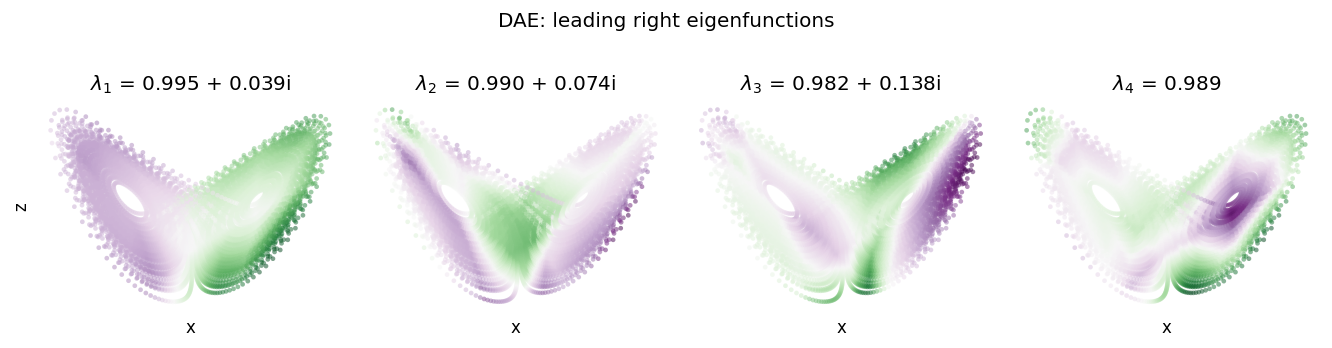

In [11]:

dae = run_autoencoder_analysis(
    name="DAE",
    model_cls=DynamicAE,
    subdir="DAE",
    prefix="DAE",
    analysis_data=lorenz63_data,
)
show_analysis(dae, lorenz63_data)


## Consistent Autoencoder

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


CAE_rep1.pt:   0%|          | 0.00/851k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


CAE_rep2.pt:   0%|          | 0.00/852k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


CAE_rep18.pt:   0%|          | 0.00/851k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


CAE_rep19.pt:   0%|          | 0.00/852k [00:00<?, ?B/s]

,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
CAE,20,0.025759,0.001928,0.019465,0.001396,NaN,NaN,0


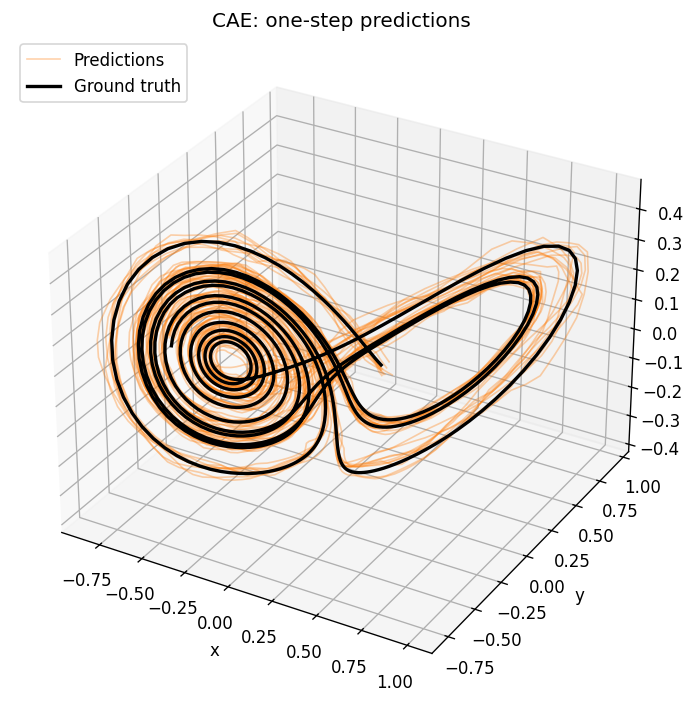

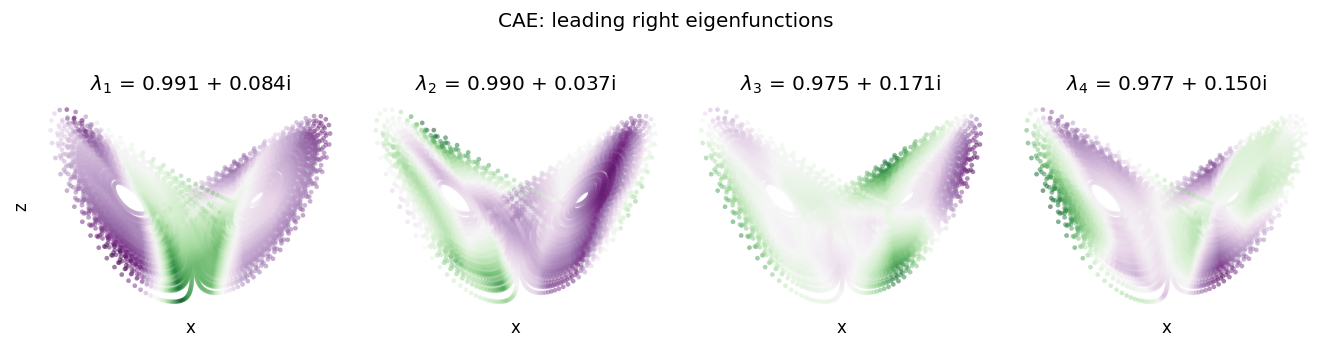

In [12]:

cae = run_autoencoder_analysis(
    name="CAE",
    model_cls=ConsistentAE,
    subdir="CAE",
    prefix="CAE",
    analysis_data=lorenz63_data,
)
show_analysis(cae, lorenz63_data)


## Comparison Summary

In [13]:

comparison = summarize_analyses([
    evop,
    linear_ols,
    krr,
    vampnets,
    dpnets,
    dae,
    cae,
])
comparison


,runs,rmse_mean,rmse_std,mae_mean,mae_std,fit_time_ms_mean,fit_time_ms_std,representative_run
method,,,,,,,,
Evolution Operator,20,0.004912,2.400790e-03,0.003221,2.351918e-03,NaN,NaN,6
Linear OLS,1,0.012912,0.000000e+00,0.008429,0.000000e+00,1.330889,0.000000,0
Kernel Ridge Regression,20,0.020953,1.912946e-15,0.012689,7.877877e-16,7157.467104,593.452231,0
VAMPNets,20,0.007805,1.247178e-03,0.004619,8.264268e-04,NaN,NaN,0
DPNets,20,0.005809,1.098060e-03,0.003574,7.600907e-04,NaN,NaN,0
DAE,20,0.007704,1.160990e-03,0.005530,8.130879e-04,NaN,NaN,0
CAE,20,0.025759,1.928493e-03,0.019465,1.396235e-03,NaN,NaN,0
